In [5]:
import matplotlib.pyplot as plt
!mamba install pandas
import pandas as pd
import numpy as np
!pip install seaborn
import seaborn as sns
%matplotlib inline

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.487 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.1                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
mambajs 0.19.13

Process pip requirements ...

Requirement numpy already satisfied.
Requirement pandas already satisfied.
Requirement matplotlib already satisfied.


In [6]:
df = pd.read_csv('data4.csv')
df.head()

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating,...,stores,id_games,achievements_count,a_count,series_count,dev_team_count,rating_norm,reviews_log,reviews_norm,score
0,https://store.steampowered.com/app/730/Counter...,Counter-Strike 2,2012-08-21,Valve,"['Action', 'Free To Play']",Free To Play,0%,1.0,"['FPS', 'Shooter', 'Multiplayer', 'Competitive...",3.57,...,['Steam'],965470,0.0,0.0,0.0,1.0,0.739130,5.379897,0.604780,0.651803
1,https://store.steampowered.com/app/2868840/Sla...,Slay the Spire 2,2026-03-05,Mega Crit,"['Indie', 'Strategy', 'Early Access']","22,99€",0%,0.0,"['Strategy', 'Roguelike', 'Card Game', 'Deckbu...",0.00,...,['Steam'],994601,0.0,0.0,1.0,1.0,0.000000,1.791759,0.201420,0.130923
2,https://store.steampowered.com/app/2050650/Res...,Resident Evil 4,2023-03-24,"CAPCOM Co., Ltd.","['Action', 'Adventure']","100,24€",-60%,27.0,"['Horror', 'Action', 'Survival Horror', 'Third...",4.58,...,"['Steam', 'PlayStation Store']",795632,34.0,0.0,28.0,7.0,0.948240,6.455199,0.725660,0.803563
3,https://store.steampowered.com/app/1172470/Ape...,Apex Legends™,2020-11-04,Respawn,"['Action', 'Adventure', 'Free To Play']",Free To Play,0%,0.0,"['Free to Play', 'Battle Royale', 'Multiplayer...",3.63,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",290856,12.0,21.0,1.0,3.0,0.751553,7.799753,0.876807,0.832968
4,https://store.steampowered.com/app/230410/Warf...,Warframe,2013-03-25,Digital Extremes,"['Action', 'RPG', 'Free To Play']",Free To Play,0%,17.0,"['Free to Play', 'Looter Shooter', 'Action RPG...",3.42,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",766,259.0,0.0,0.0,14.0,0.708075,7.663408,0.861480,0.807788


In [8]:
df = df.drop_duplicates()

plt.figure(figsize=(10, 5))
sns.histplot(df['series_count'], bins=15)
plt.xlabel('Количнство платформ')
plt.ylabel('Количество игр')
plt.title('Распределение количества платформ')
plt.show()

In [28]:
#функция проверяет, является ли значение строкой со списком, и если да, то считает, сколько элементов в этом списке
def get_len(x):
    if not isinstance(x, str):
        return 0

    x = x.strip()

    if x == "[]":
        return 0

    if x.startswith("[") and x.endswith("]"):
        inside = x[1:-1].strip()

        if inside == "":
            return 0

        return len(inside.split(","))

    return 0

In [29]:
df['genre_count'] = df['genre'].apply(get_len)
df['tags_count'] = df['tags'].apply(get_len)

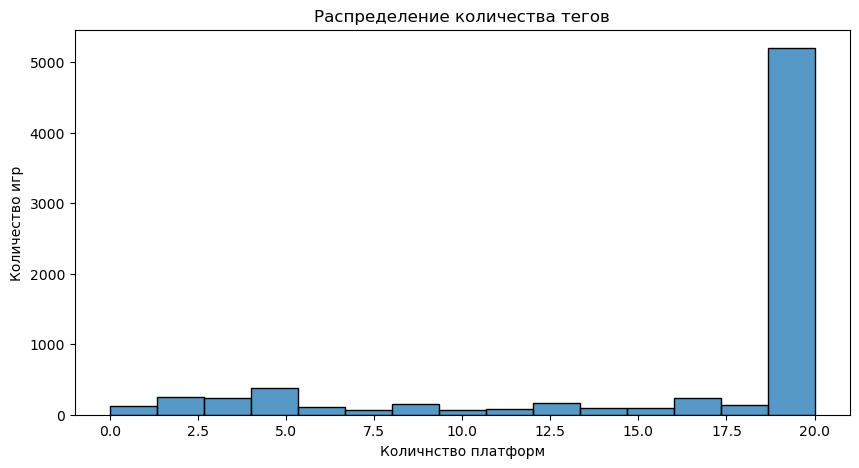

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(df['tags_count'], bins=15)
plt.xlabel('Количнство платформ')
plt.ylabel('Количество игр')
plt.title('Распределение количества тегов')
plt.show()

Сформулирую гипотезы

1. Чем больше, жанров охватывает игра, тем выше ее успешность
2. Чем больше у платформы тегов, тем выше ее успешность
3. Игры с большими сериями, имеют более высокие рейтинги

Гипотеза 1

In [31]:
platform_summary = df.groupby('genre_count')['score'].agg(['count', 'mean', 'median']).reset_index()
platform_summary

,genre_count,count,mean,median
0,0,53,0.533441,0.583426
1,1,1511,0.494794,0.537213
2,2,2281,0.458507,0.503151
3,3,1947,0.413571,0.472882
4,4,1016,0.371934,0.437972
5,5,450,0.385508,0.458247
6,6,120,0.384677,0.457896
7,7,31,0.334673,0.349126
8,8,13,0.219676,0.117601
9,9,1,0.709821,0.709821


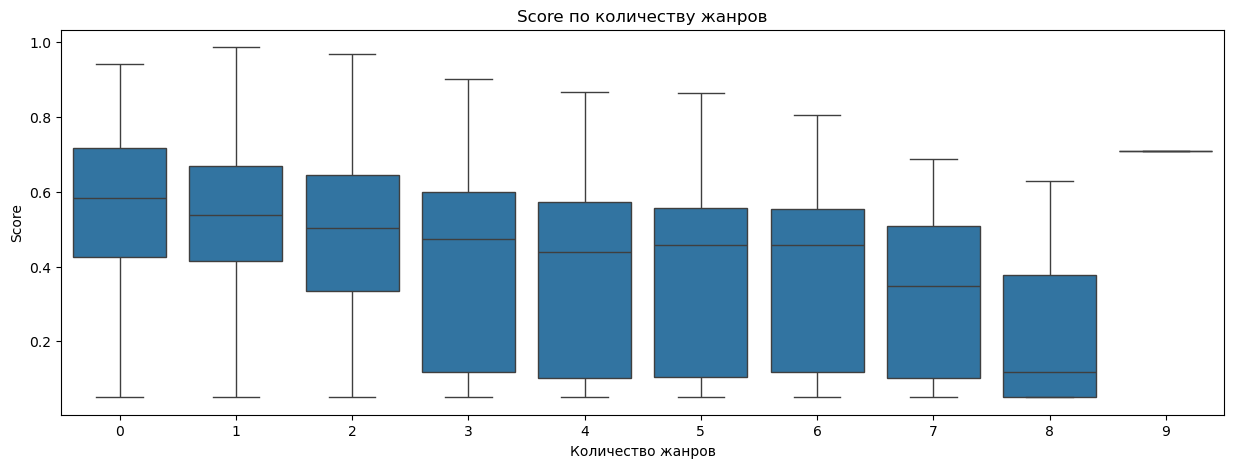

In [32]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=df, x='genre_count', y='score')
plt.title('Score по количеству жанров')
plt.xlabel('Количество жанров')
plt.ylabel('Score')
plt.show()

<Axes: >

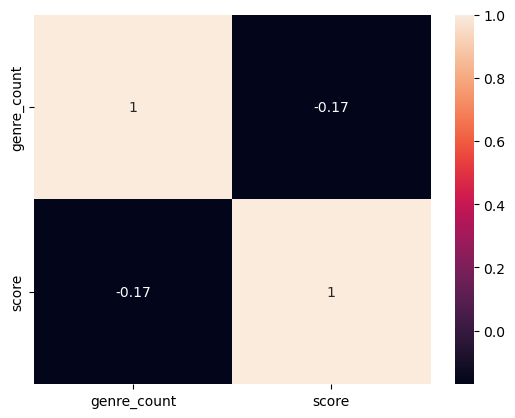

In [38]:
sns.heatmap(df[['genre_count', 'score']].corr(), annot = True)

Как мы можем увидеть, самый лучший score сосредоточен в среднем сегменте количества жанров. При увеличении же genre_count, count падает.
Что говорит нам о том, что большое количество жанров, не влияет положительно на Score. А значит гипотеза не верна.

Гипотеза 2

In [33]:
platform_summary = df.groupby('tags_count')['score'].agg(['count', 'mean', 'median']).reset_index()
platform_summary

,tags_count,count,mean,median
0,0,18,0.540504,0.538121
1,1,104,0.593226,0.553506
2,2,255,0.466251,0.465068
3,3,243,0.501208,0.557564
4,4,243,0.499811,0.588748
5,5,140,0.497909,0.552777
6,6,111,0.441597,0.496712
7,7,71,0.457762,0.494449
8,8,68,0.423046,0.471812
9,9,83,0.434331,0.474046


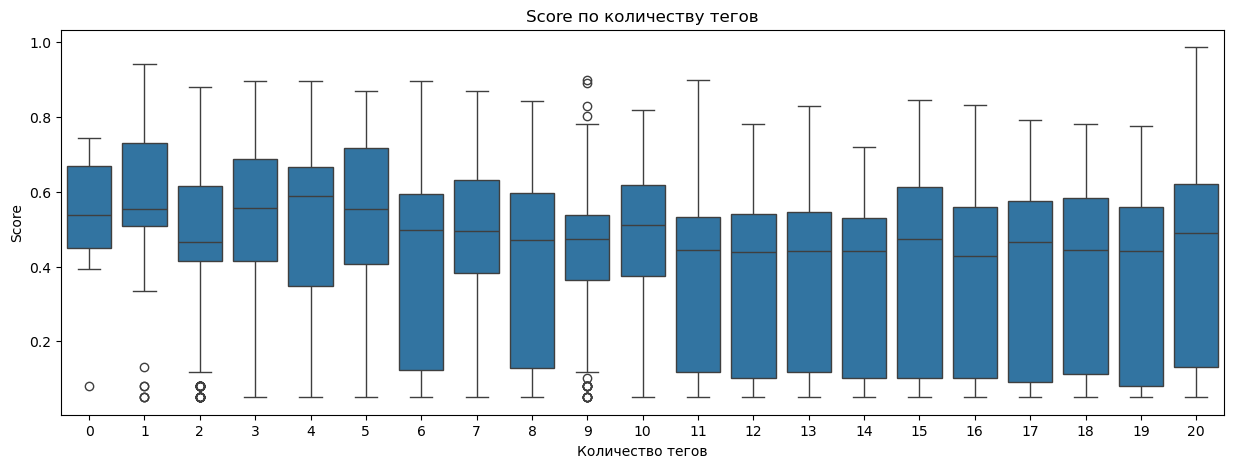

In [34]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=df, x='tags_count', y='score')
plt.title('Score по количеству тегов')
plt.xlabel('Количество тегов')
plt.ylabel('Score')
plt.show()

<Axes: >

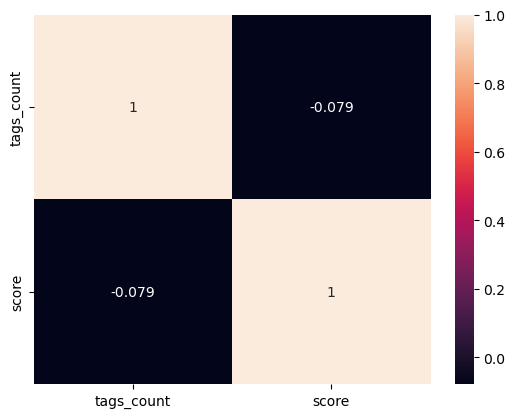

In [37]:
sns.heatmap(df[['tags_count', 'score']].corr(), annot = True)

Как мы можем увидеть, из графиок и корреляции равной -0.079, количество тегов, не влияют на рейтинг. Гипотеза не верна.

Гипотеза 3

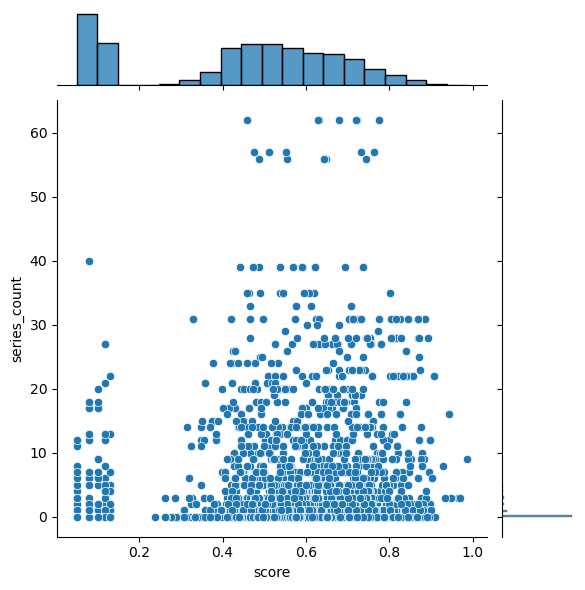

In [27]:
sns.jointplot(x='score', y='series_count', data=df, kind='scatter')

как мы можем увидеить, у игр с 0 серией огромный разброс в рейтинге, в то время как большие серии имеют приемущественно высокие рейтинги.
это происходит в связи с тем, что успешный релиз - дает мотивацию делать новые части чтобы заработать еще деньги на успешном проекте.
Если проект живет много лет - значит он успешен - хороший рейтинг. Значит наша гипотеза верна.

<Axes: >

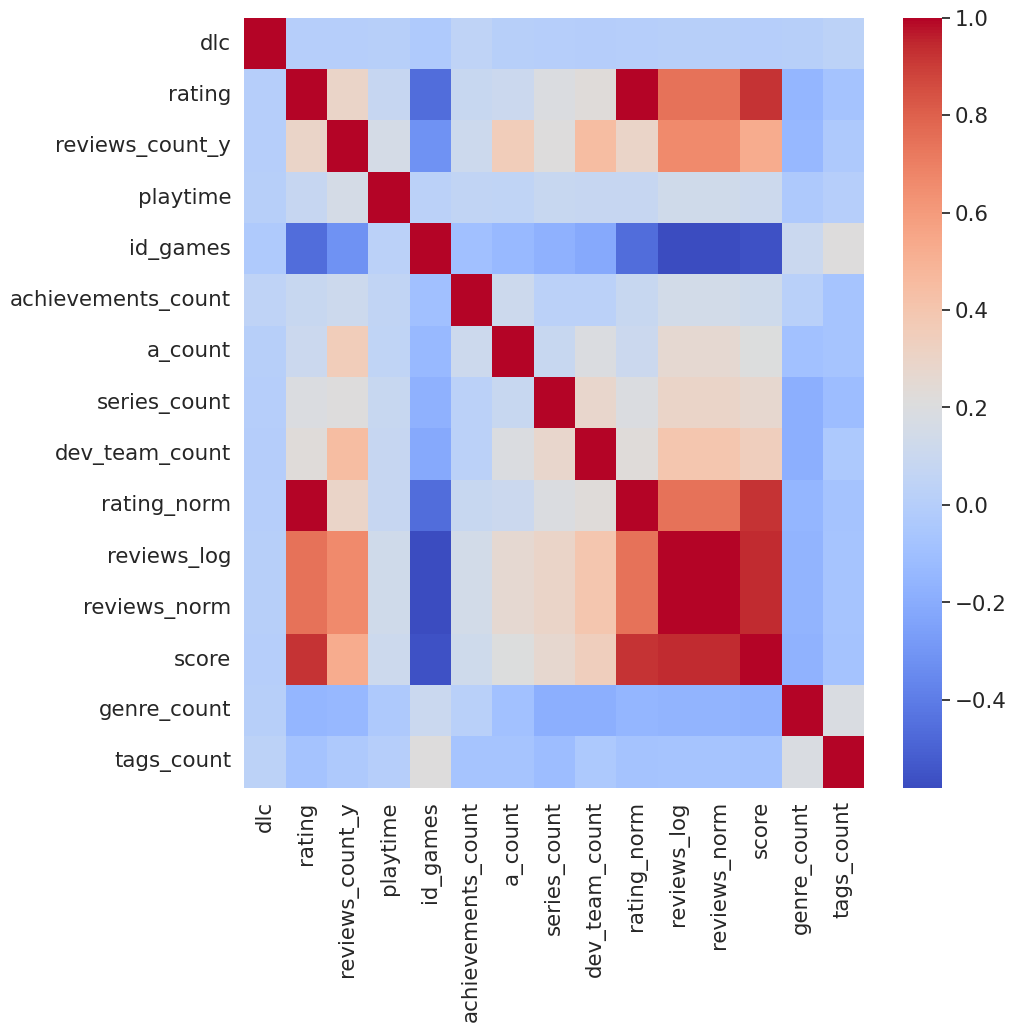

In [42]:
correlations_data = df.corr(numeric_only = True)['score'].sort_values()
sns.set(font_scale=1.4)
plt.figure(figsize=(10,10))

sns.heatmap(df.corr(numeric_only = True), cbar=True, cmap='coolwarm')